In [1]:
library(repr)
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
options(repr.plot.width=8, repr.plot.height=6, repr.plot.res = 300)
library(showtext)
font_add_google("Lato", "lato")
showtext_opts(dpi = 300)
showtext_auto()

Loading required package: sysfonts

Loading required package: showtextdb



In [3]:
df <- read_csv("glaucoma_io_group_gaze.csv")
df <- df |> 
    mutate(
        inside = factor(inside),
        inside = fct_recode(inside, "outside" = "0", "inside" = "1"),
        PID = factor(PID)
    ) |>
    rename(
        building_location = inside,
        group = category
    )

Rows: 1353 Columns: 6
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (2): hitObjectColliderName, category
dbl (4): PID, inside, GroupCount, median_clusterDuration

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [4]:
# df |> ggplot(aes(x = group, y = median_clusterDuration, color = building_location)) +
#  geom_point(position = position_dodge(0.4)) +
#  theme_minimal()
df |> head()

PID,hitObjectColliderName,group,building_location,GroupCount,median_clusterDuration
<fct>,<chr>,<chr>,<fct>,<dbl>,<dbl>
2002,Building_100,control,outside,10,0.3832777
2002,Building_101,control,outside,21,0.5343921
2002,Building_102,control,outside,4,0.9105198
2002,Building_108,control,outside,2,0.5216707
2002,Building_109,control,outside,1,0.2677307
2002,Building_140,control,outside,1,0.2887373


Warning message:
“Removed 83 rows containing non-finite outside the scale range (`stat_density()`).”


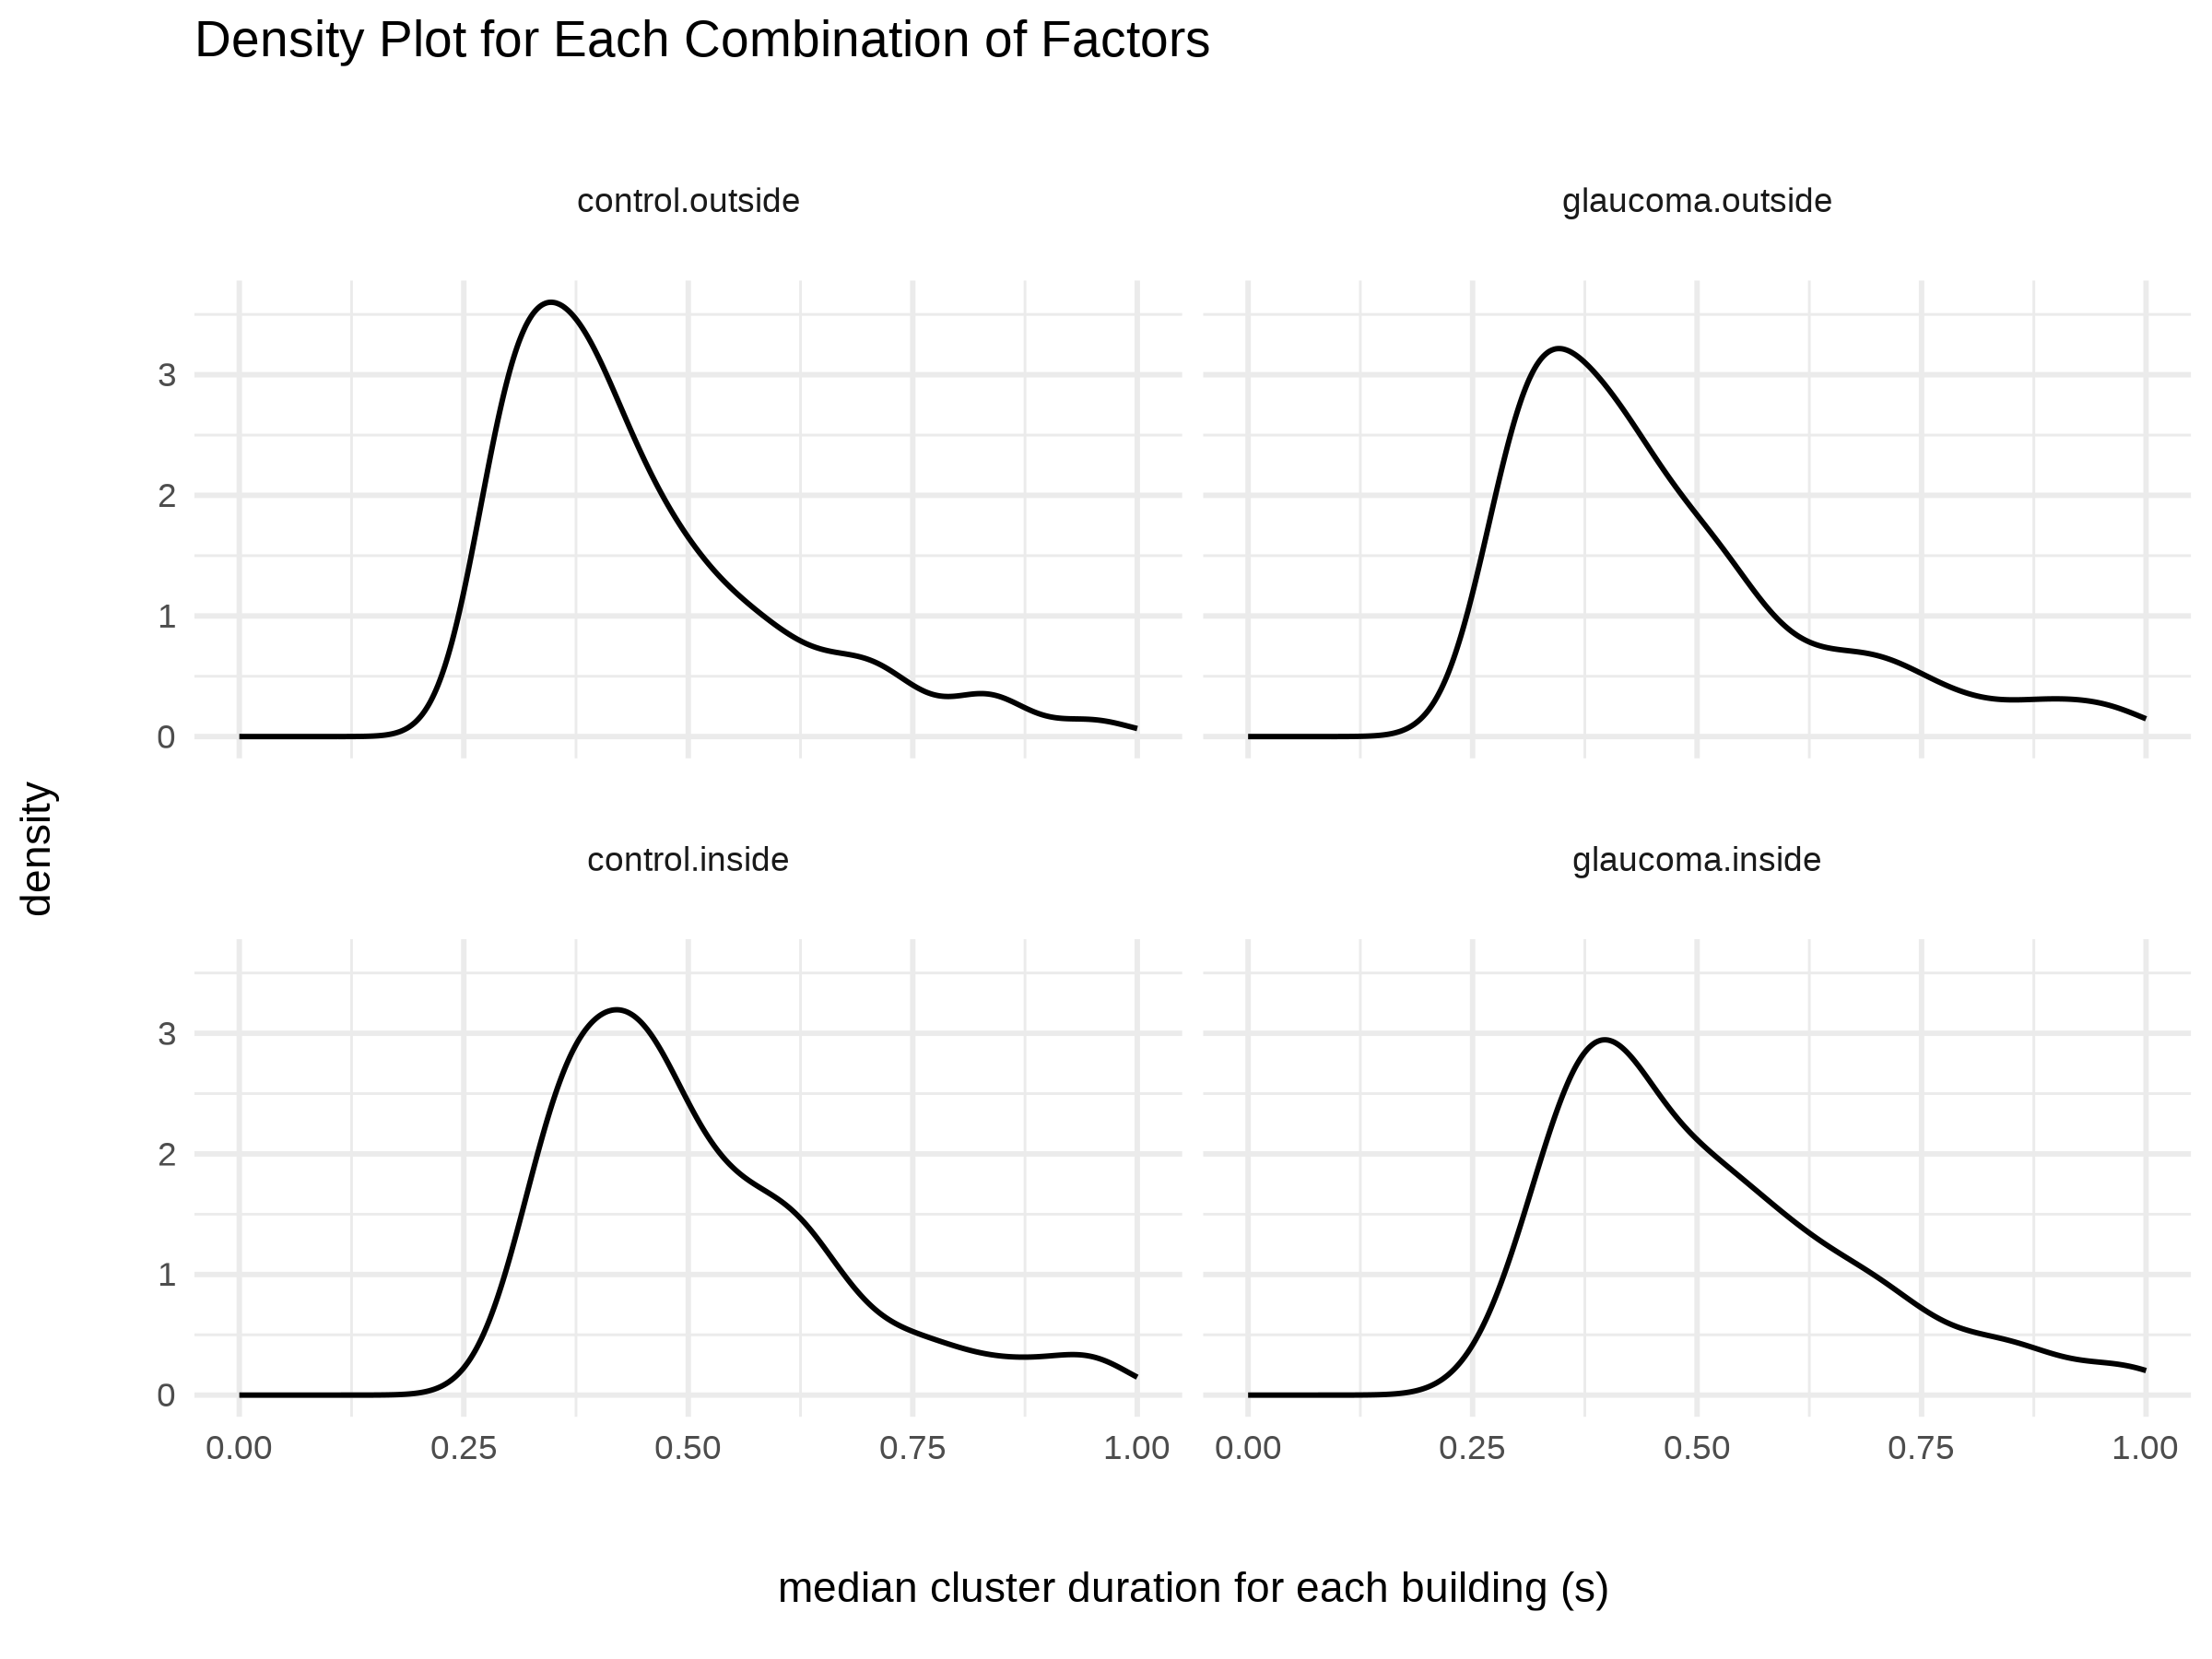

In [5]:
fig <- df |>
  ggplot(aes(x = median_clusterDuration)) +
  geom_density(alpha = 0.6) +  # Adjust alpha for transparency
  xlim(0, 1) +
  facet_wrap(~ interaction(group, building_location)) +  # Facet by the interaction of the two factors
  theme_minimal() +
  labs(title = "Density Plot for Each Combination of Factors",
       x = "median cluster duration for each building (s)",
       y = "density")
fig
#ggsave("naisu_only_location.svg", fig)

In [6]:
library(lme4)
library(emmeans)
library(performance)
library(pbkrtest)
library(lmerTest)


Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


Welcome to emmeans.
Caution: You lose important information if you filter this package's results.
See '? untidy'


Attaching package: ‘lmerTest’


The following object is masked from ‘package:lme4’:

    lmer


The following object is masked from ‘package:stats’:

    step




In [10]:
# Fit a generalized linear mixed model (GLMM) using glmer
# Assuming a dataset 'data' with a binary response variable 'y', 
# a fixed effect 'x', and a random effect 'group'
df_filter <- df %>% filter(median_clusterDuration < 3)
model <- glmer(median_clusterDuration ~ building_location + group + (1 | PID) + (1 | hitObjectColliderName), data = df_filter, Gamma(link = "inverse"))
# model0 <- glmer(median_clusterDuration ~ 1 + (1 | PID) + (1| hitObjectColliderName), data = df, Gamma(link = "inverse"))

In [8]:
#an <- anova(model, model0)

ERROR: Error in eval(expr, envir, enclos): object 'model0' not found


In [11]:
model

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( inverse )
Formula: median_clusterDuration ~ building_location + group + (1 | PID) +  
    (1 | hitObjectColliderName)
   Data: df_filter
       AIC        BIC     logLik   deviance   df.resid 
-1006.3803  -975.1376   509.1901 -1018.3803       1343 
Random effects:
 Groups                Name        Std.Dev.
 hitObjectColliderName (Intercept) 0.3262  
 PID                   (Intercept) 0.1480  
 Residual                          0.3667  
Number of obs: 1349, groups:  hitObjectColliderName, 116; PID, 18
Fixed Effects:
            (Intercept)  building_locationinside            groupglaucoma  
                 2.5161                  -0.4614                  -0.1023  

In [12]:
anova(model)
library(car)
Anova(model)
anova(model)

,npar,Sum Sq,Mean Sq,F value
,<int>,<dbl>,<dbl>,<dbl>
building_location,1,4.5917721,4.5917721,34.142561
group,1,0.2239768,0.2239768,1.665401


Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode


The following object is masked from ‘package:purrr’:

    some




,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
building_location,15.4820637,1,8.329188e-05
group,0.7044884,1,4.012796e-01


,npar,Sum Sq,Mean Sq,F value
,<int>,<dbl>,<dbl>,<dbl>
building_location,1,4.5917721,4.5917721,34.142561
group,1,0.2239768,0.2239768,1.665401


In [13]:
lme_model <- lmer(median_clusterDuration ~ building_location + group + (1 | PID) + (1| hitObjectColliderName), data = df)
summary(lme_model)

anova(lme_model)

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: median_clusterDuration ~ building_location + group + (1 | PID) +  
    (1 | hitObjectColliderName)
   Data: df

REML criterion at convergence: 851.9

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.7131 -0.4020 -0.1306  0.2031 12.6461 

Random effects:
 Groups                Name        Variance Std.Dev.
 hitObjectColliderName (Intercept) 0.019245 0.13873 
 PID                   (Intercept) 0.009568 0.09781 
 Residual                          0.096566 0.31075 
Number of obs: 1353, groups:  hitObjectColliderName, 116; PID, 18

Fixed effects:
                         Estimate Std. Error        df t value Pr(>|t|)    
(Intercept)               0.44900    0.04020  28.02805  11.168 7.86e-12 ***
building_locationinside   0.12122    0.03328 110.95058   3.643 0.000411 ***
groupglaucoma             0.06263    0.04918  15.97645   1.274 0.221050    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 

,Sum Sq,Mean Sq,NumDF,DenDF,F value,Pr(>F)
,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
building_location,1.2815187,1.2815187,1,110.95058,13.270901,0.0004114419
group,0.1566168,0.1566168,1,15.97645,1.621861,0.2210499216


In [14]:
# Create a reference grid
ref_grid <- ref_grid(model)
02
# Regrid to transform the reference grid
# This is particularly useful for gamma models with inverse link
new_grid <- regrid(ref_grid, transform = "response")

# Now use the transformed grid for emmeans
emm <- emmeans(new_grid, ~ group)

# View results
summary(emm)
pairs(emm, adjust = "bonferroni")
pairs(emm, adjust = "tukey")


[1] 2

,group,response,SE,df,asymp.LCL,asymp.UCL
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,control,0.4420723,0.02260853,Inf,0.3977604,0.4863842
2,glaucoma,0.4632464,0.02550712,Inf,0.4132534,0.5132395


 contrast           estimate     SE  df z.ratio p.value
 control - glaucoma  -0.0212 0.0254 Inf  -0.834  0.4043

Results are averaged over the levels of: building_location 

 contrast           estimate     SE  df z.ratio p.value
 control - glaucoma  -0.0212 0.0254 Inf  -0.834  0.4043

Results are averaged over the levels of: building_location 

Warning message in grid.Call.graphics(C_segments, x$x0, x$y0, x$x1, x$y1, x$arrow):
“semi-transparency is not supported on this device: reported only once per page”


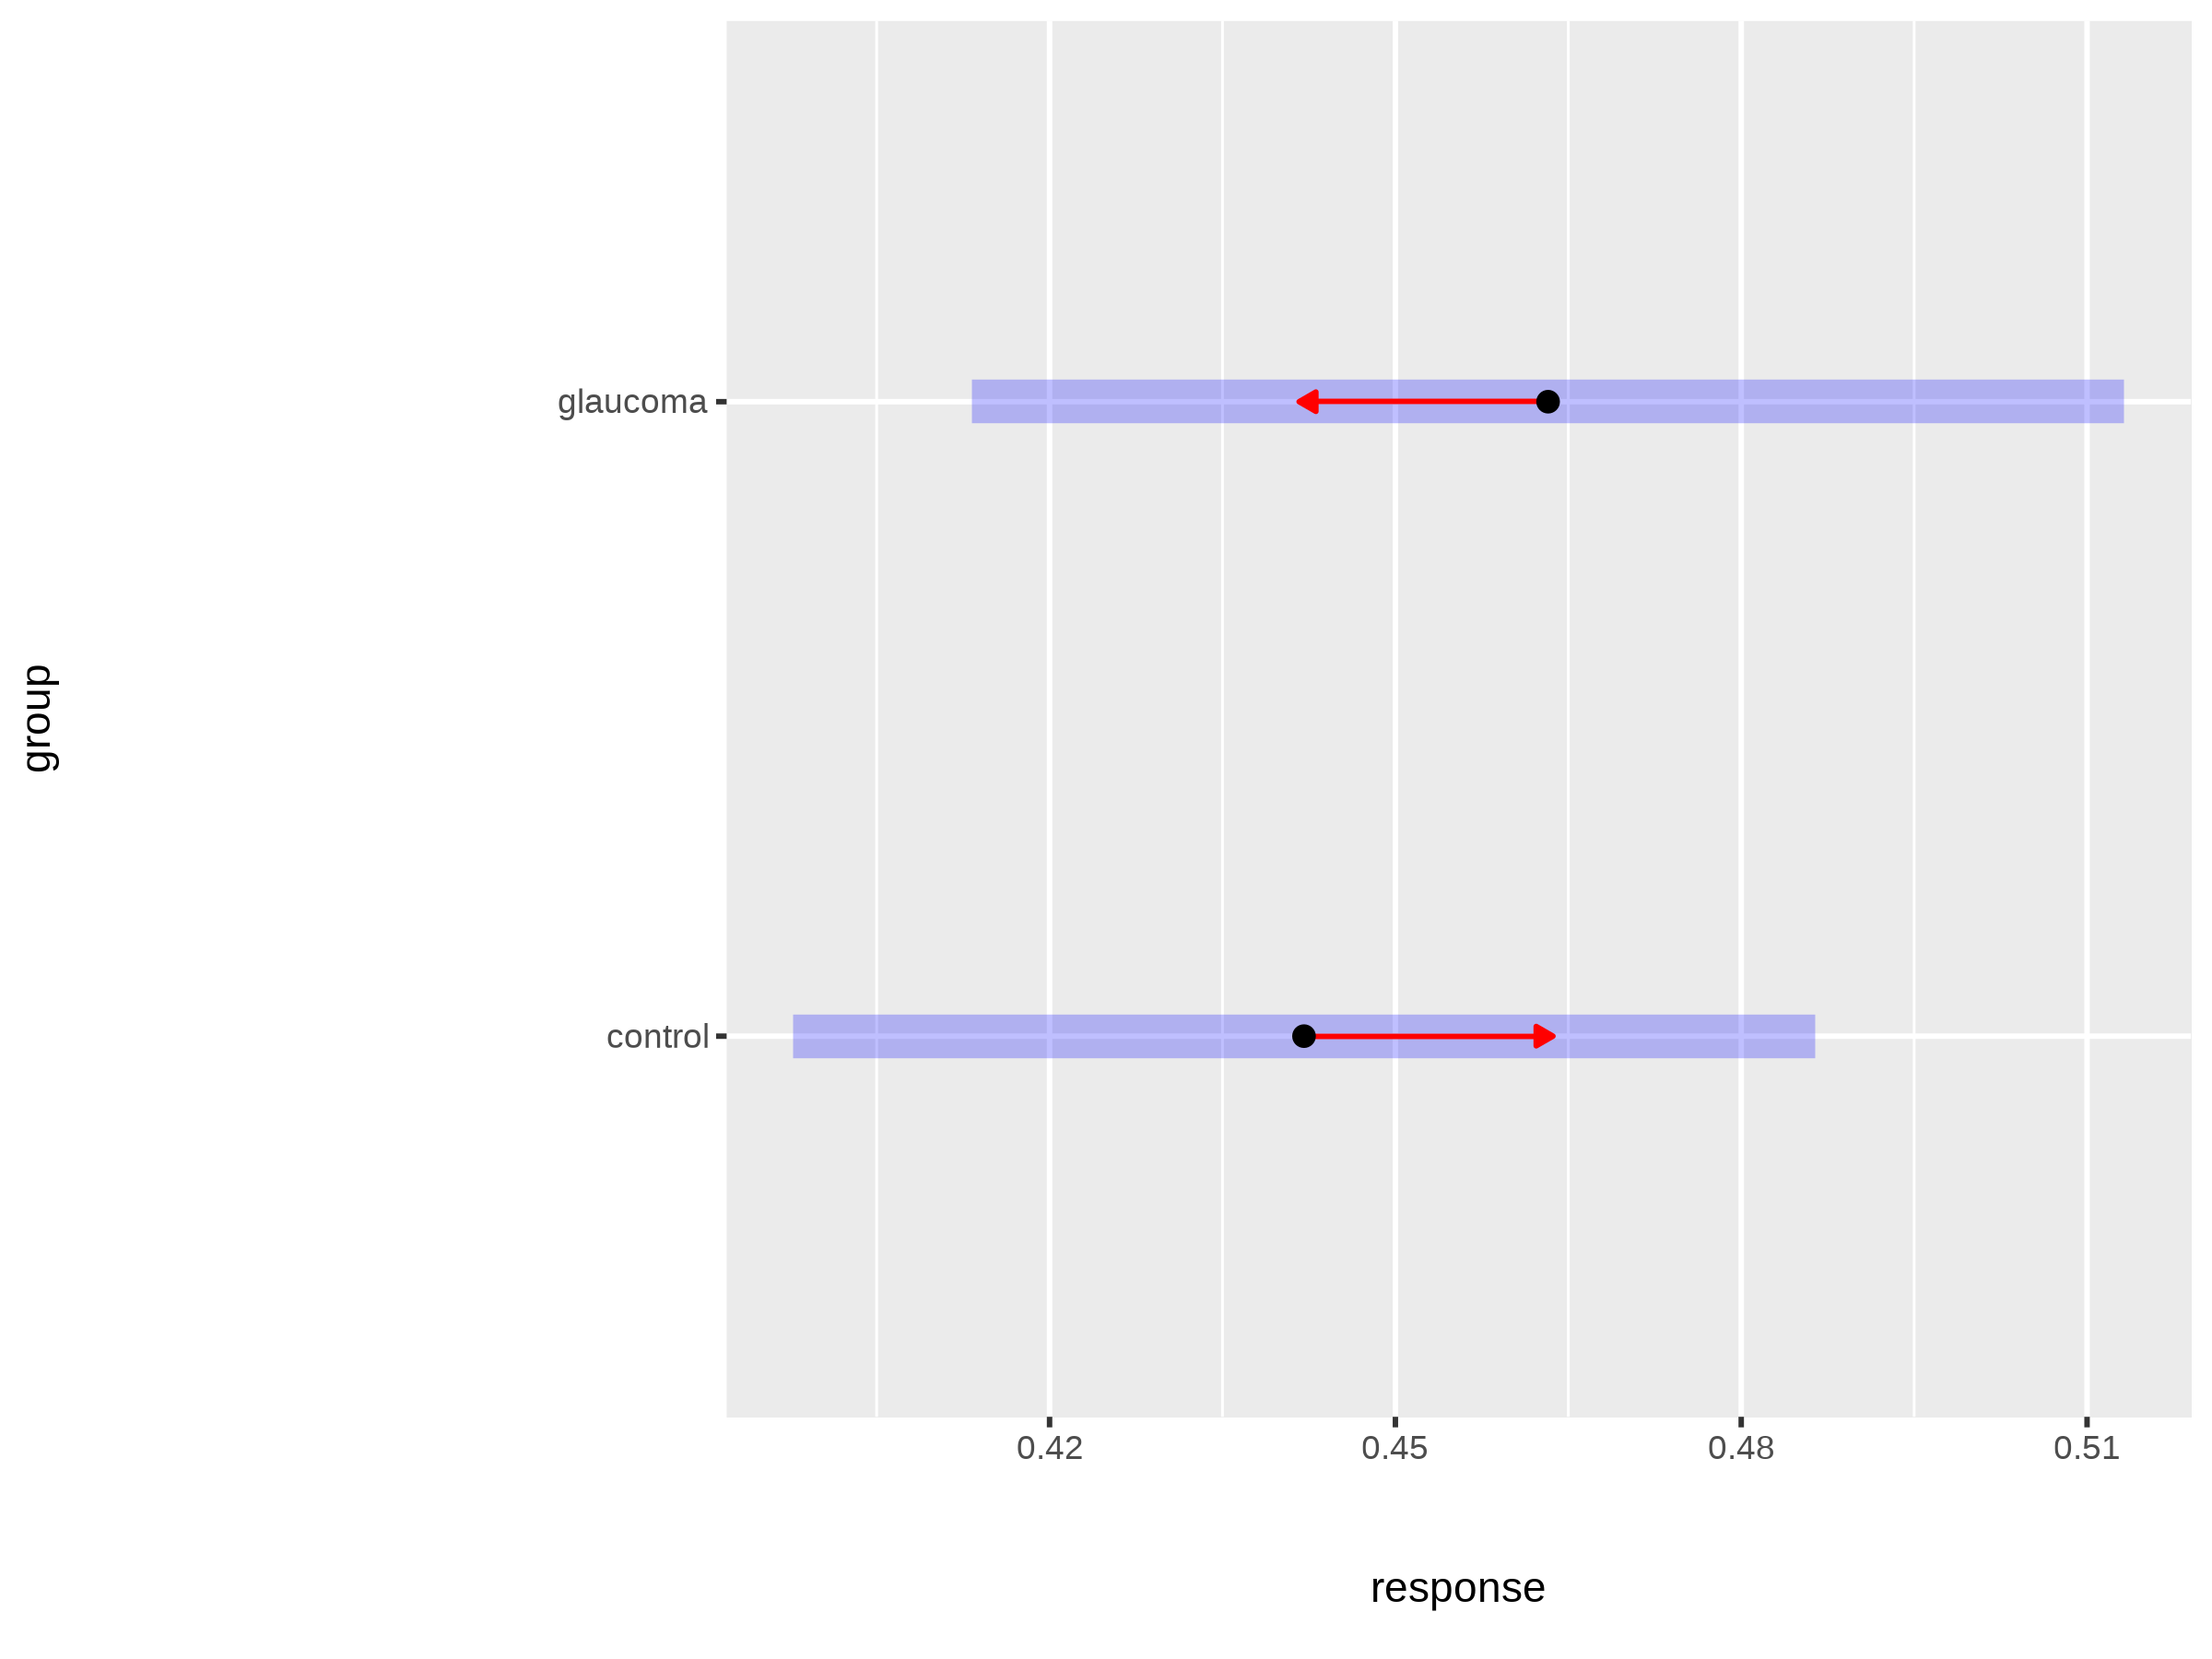

In [15]:
plot(emm, comparisons = TRUE)

In [16]:
r2_nakagawa(model, by_group = TRUE)
r2_nakagawa(model)

,Level,R2
,<chr>,<dbl>
,Level 1,0.02673548
PID,PID,0.03045502
hitObjectColliderName,hitObjectColliderName,0.16647961


# R2 for Mixed Models

  Conditional R2: 0.578
     Marginal R2: 0.176

In [17]:
df_node <- read_csv("io_node_group_gaze.csv")

df_node <- df_node |> 
    mutate(
        inside = factor(inside),
        inside = fct_recode(inside, "outside" = "0", "inside" = "1"),
        hitObjectColliderName = factor(hitObjectColliderName),
        PID = factor(PID),
        category = factor(category, levels = c("peripheral", "central", "control"))
    ) |>
    rename(
        building_location = inside,
        group = category,
        building = hitObjectColliderName,
        duration = clusterDuration
    )

df_node |> head()


Rows: 17925 Columns: 8
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (2): hitObjectColliderName, category
dbl (6): clusterID, sampleNr, clusterDuration, PID, inside, connections

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


clusterID,sampleNr,duration,building,PID,group,building_location,connections
<dbl>,<dbl>,<dbl>,<fct>,<fct>,<fct>,<fct>,<dbl>
2,121,1.3477349,TaskBuilding_35,4003,peripheral,inside,17
7,35,0.3888457,Building_166,4003,peripheral,inside,12
9,39,0.4330869,Building_168,4003,peripheral,inside,11
10,33,0.3671408,TaskBuilding_42,4003,peripheral,inside,12
12,57,0.6329131,Building_166,4003,peripheral,inside,12
13,56,0.6199913,Building_166,4003,peripheral,inside,12


In [18]:
pid_order <- df_node |> arrange(group) |> distinct(PID) |> pull(PID)

`summarise()` has grouped output by 'PID', 'building', 'group', 'building_location'. You can override using the
`.groups` argument.


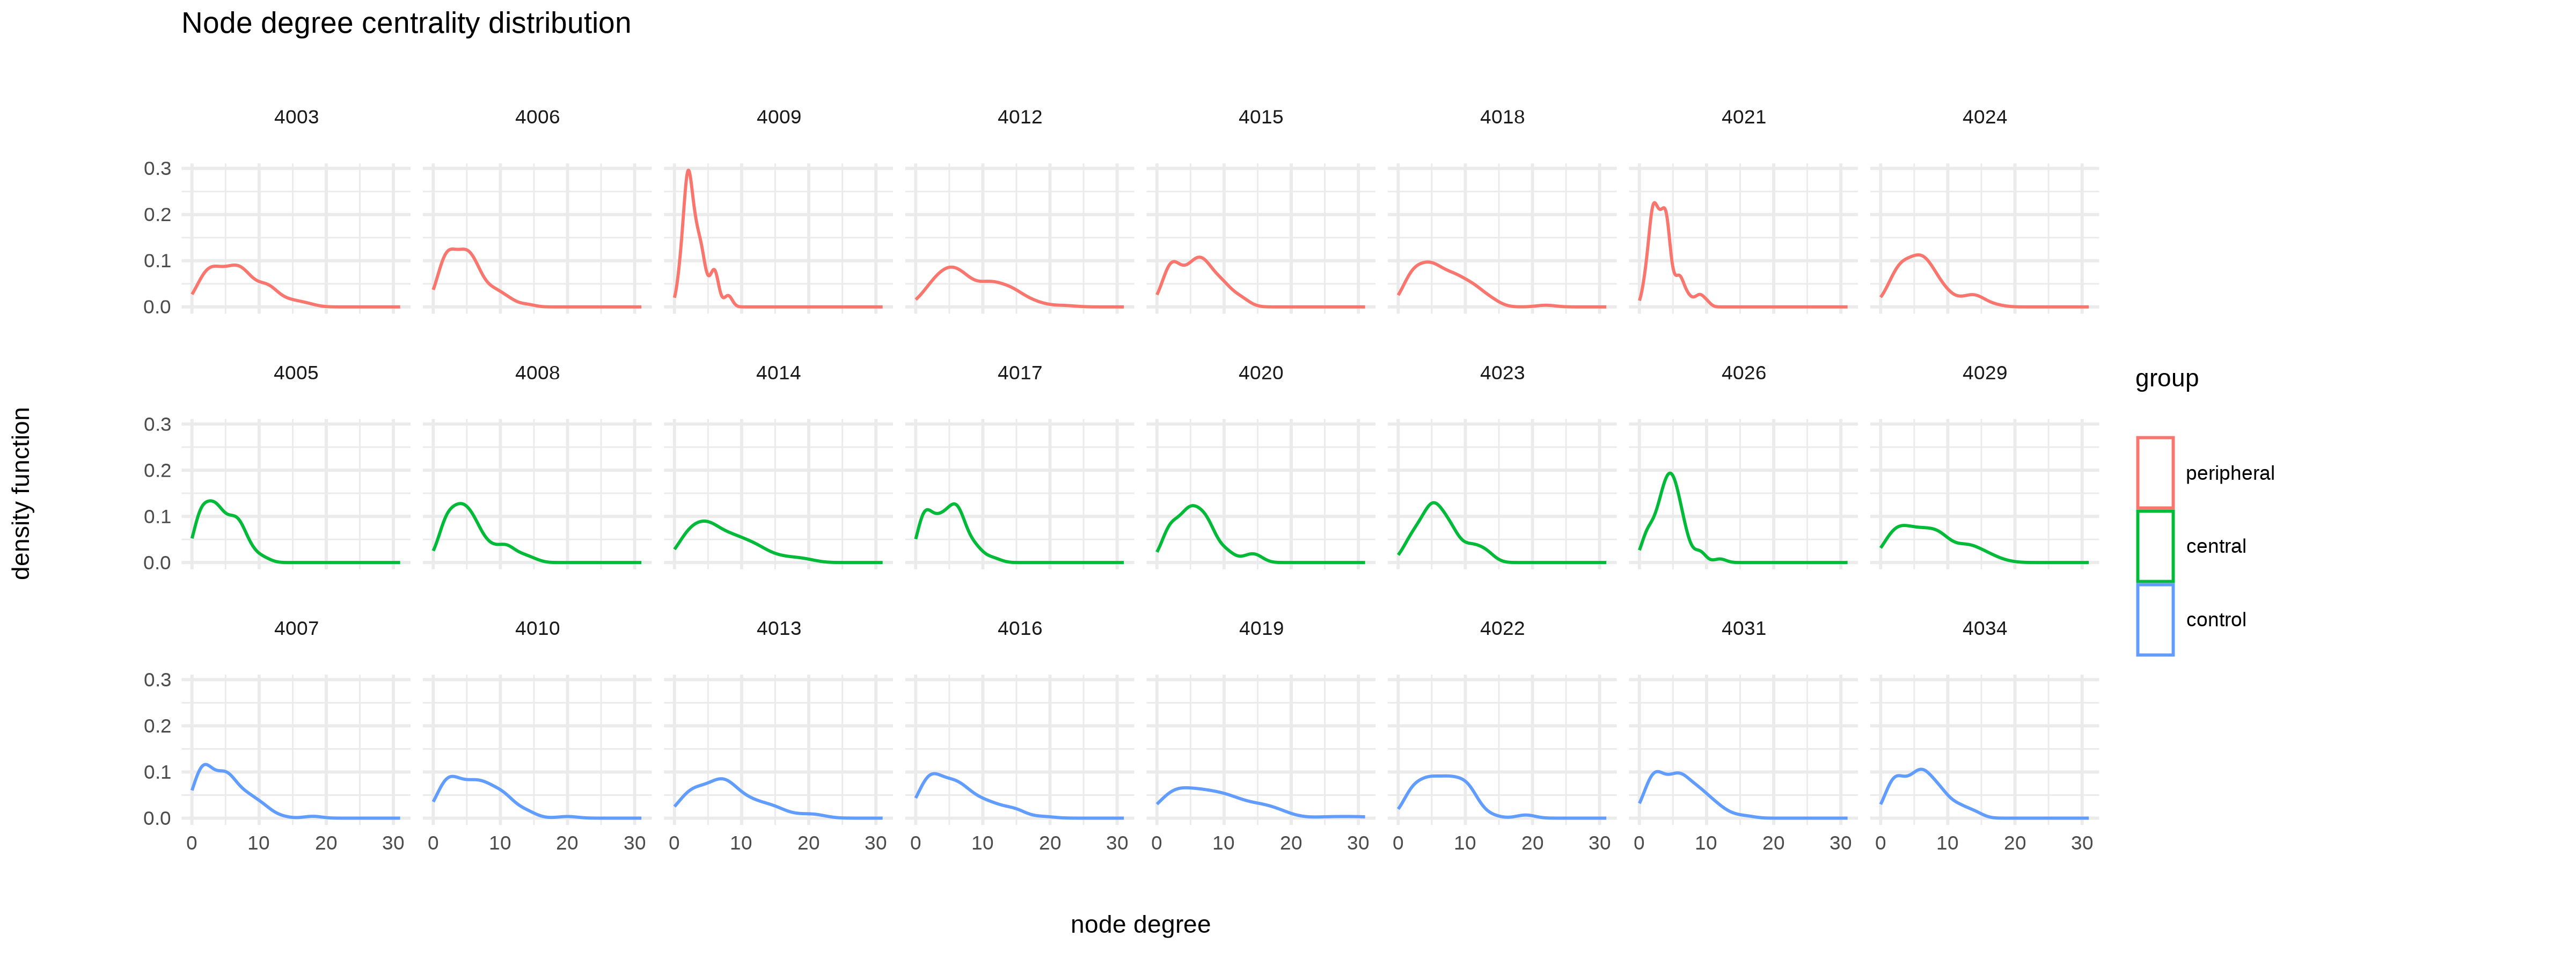

In [19]:
options(repr.plot.width=16, repr.plot.height=6, repr.plot.res = 600)
fig <- df_node |>
    group_by(PID, building, group, building_location, connections) |>
    summarise(median_duration = median(duration)) |>
    ungroup() |>
    ggplot(aes(x = connections, group = PID, color = group)) +
      # geom_histogram(bins = 50) +
      geom_density(alpha = 0.6) +  # Adjust alpha for transparency
      facet_wrap(
          ~ factor(PID, pid_order),
          ncol = 8
      ) +  # Facet by the interaction of the two factors
      theme_minimal() +
      labs(title = "Node degree centrality distribution",
           x = "node degree",
           y = "density function")
fig
ggsave("sim_indiv_node_degree_dist.svg", fig, width = 16, height = 6, units = "in", dpi = 600)
options(repr.plot.width=8, repr.plot.height=6, repr.plot.res = 300)

In [20]:
df_group_node <- df_node |>
    group_by(PID, building, group, building_location, connections) |>
    summarise(median_duration = median(duration)) |>
    ungroup()

`summarise()` has grouped output by 'PID', 'building', 'group', 'building_location'. You can override using the
`.groups` argument.


In [27]:
# peripheral central control

group_df_node <- df_node |> group_by(group) |> group_split()

[1] 3

In [30]:
# connections
ks.test(group_df_node[[1]] |> pull(connections), group_df_node[[2]] |> pull(connections))
ks.test(group_df_node[[1]] |> pull(connections), group_df_node[[3]] |> pull(connections))
ks.test(group_df_node[[2]] |> pull(connections), group_df_node[[3]] |> pull(connections))

Warning message in ks.test.default(pull(group_df_node[[1]], connections), pull(group_df_node[[2]], :
“p-value will be approximate in the presence of ties”



	Asymptotic two-sample Kolmogorov-Smirnov test

data:  pull(group_df_node[[1]], connections) and pull(group_df_node[[2]], connections)
D = 0.070928, p-value = 2.091e-12
alternative hypothesis: two-sided


Warning message in ks.test.default(pull(group_df_node[[1]], connections), pull(group_df_node[[3]], :
“p-value will be approximate in the presence of ties”



	Asymptotic two-sample Kolmogorov-Smirnov test

data:  pull(group_df_node[[1]], connections) and pull(group_df_node[[3]], connections)
D = 0.083856, p-value < 2.2e-16
alternative hypothesis: two-sided


Warning message in ks.test.default(pull(group_df_node[[2]], connections), pull(group_df_node[[3]], :
“p-value will be approximate in the presence of ties”



	Asymptotic two-sample Kolmogorov-Smirnov test

data:  pull(group_df_node[[2]], connections) and pull(group_df_node[[3]], connections)
D = 0.15109, p-value < 2.2e-16
alternative hypothesis: two-sided


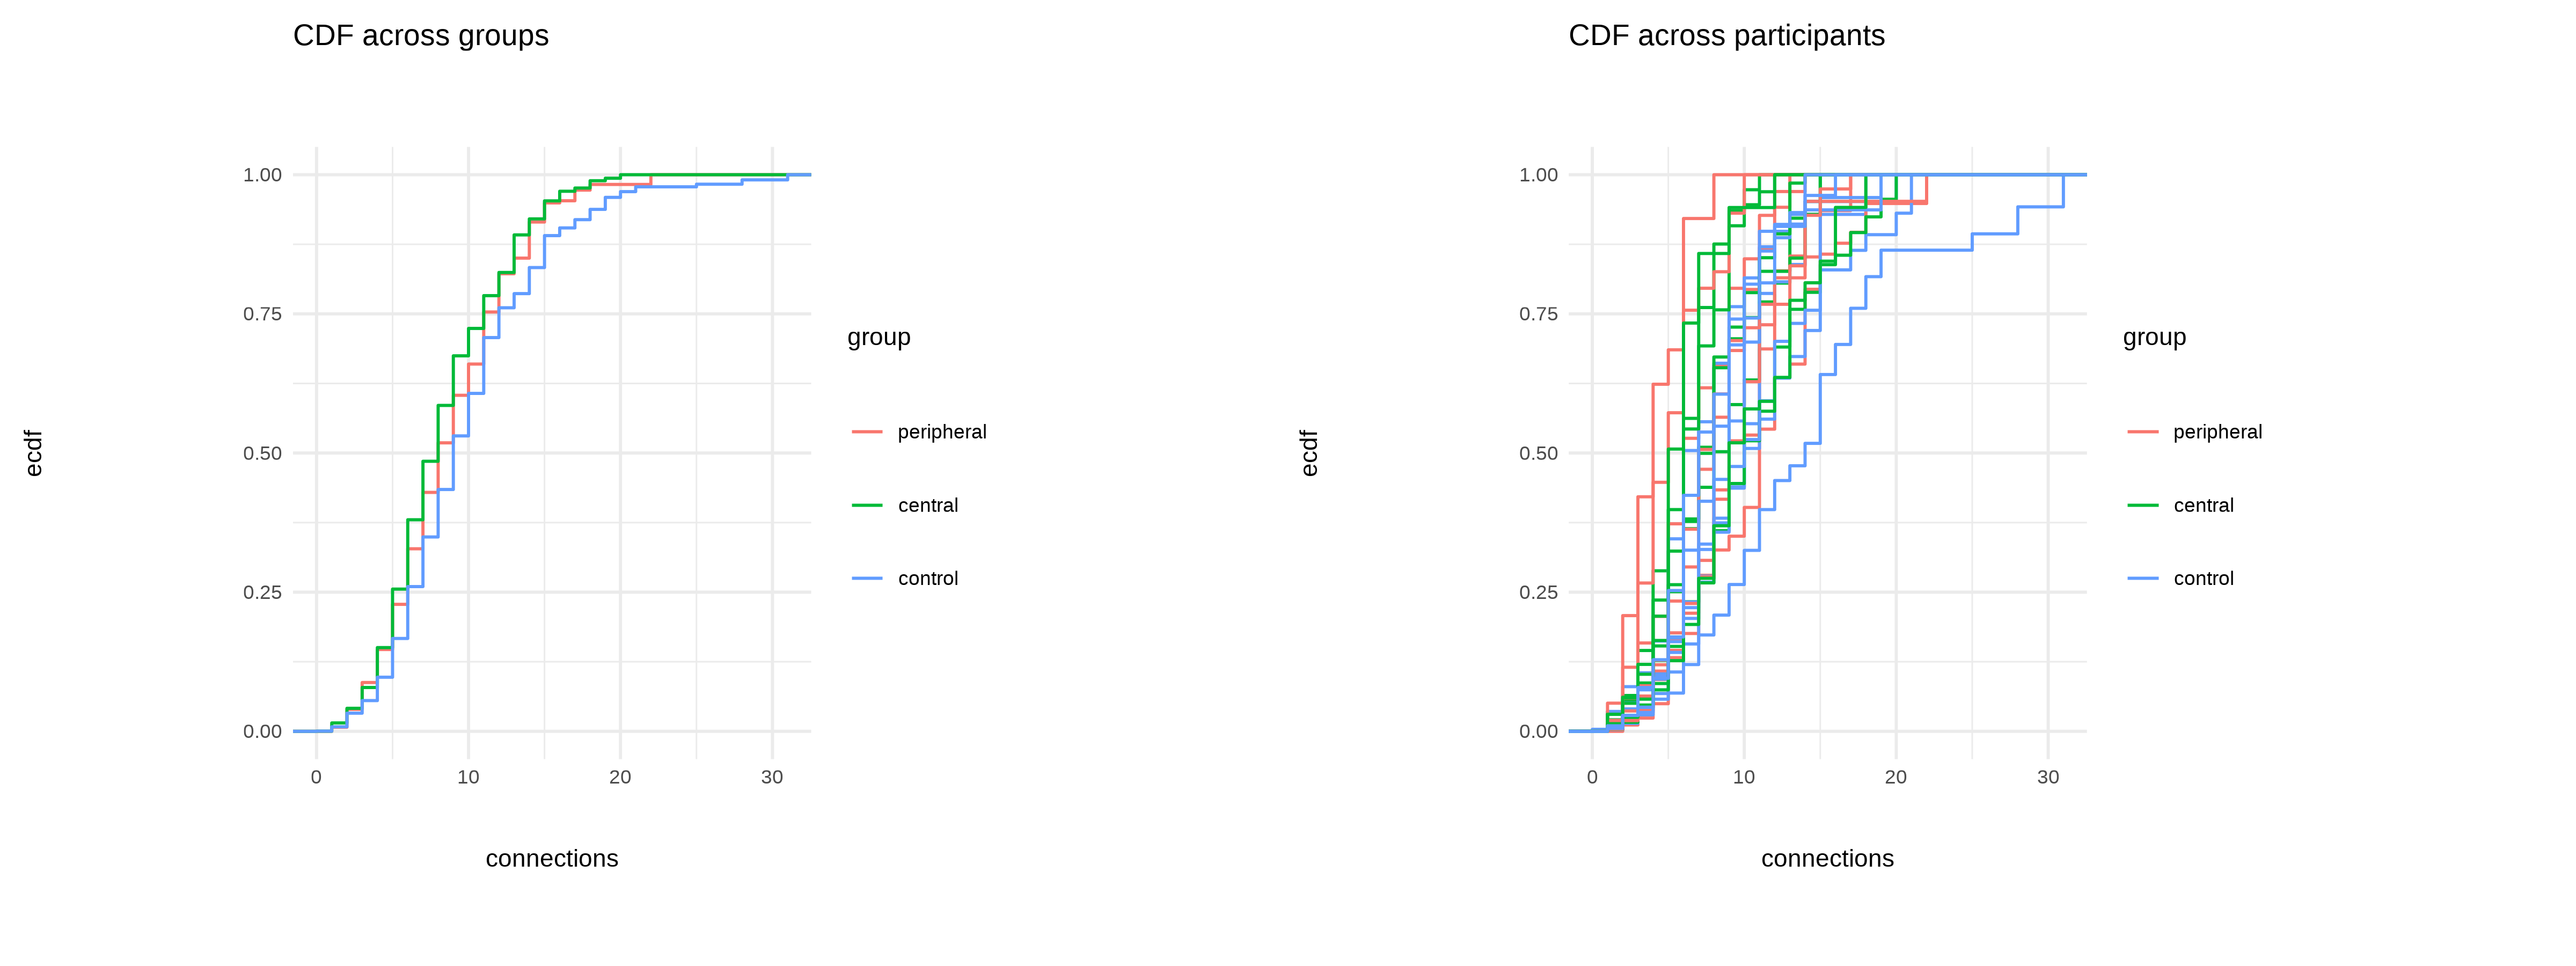

In [45]:
library(patchwork)
fig_group <- ggplot(df_node, aes(connections, group = group, color = group)) +
  stat_ecdf(geom = "step") +
  labs(title = "CDF across groups") +
  theme_minimal()
fig_participants <- ggplot(df_node, aes(connections, group = PID, color = group)) +
  stat_ecdf(geom = "step") +
  labs(title = "CDF across participants") + 
  theme_minimal()
options(repr.plot.width=16, repr.plot.height=6, repr.plot.res = 300)
fig_group | fig_participants
options(repr.plot.width=8, repr.plot.height=6, repr.plot.res = 300)
ggsave("group_node_degree_ecdf.svg", fig_group | fig_participants, width = 16, height = 6, units = "in", dpi = 300)

In [72]:
plot_group_cdf_with_ribbon <- function(df, value_col, individual_col, group_col = NULL,
                                       probs = c(0.05, 0.95), x_points = 200) {
  # Create x grid
  x_grid <- df %>% pull({{ value_col }}) %>% range() %>%
    (\(rng) seq(rng[1], rng[2], length.out = x_points))()

  # Compute ECDFs
  ecdf_df <- df %>%
    nest(data = -c({{ group_col }}, {{ individual_col }})) %>%
    mutate(ecdf = map(data, ~ ecdf(pull(.x, {{ value_col }})))) %>%
    crossing(x = x_grid) %>%
    mutate(y = map2_dbl(ecdf, x, ~ .x(.y))) %>%
    select({{ group_col }}, {{ individual_col }}, x, y)

  # Summarize across individuals
  ecdf_summary <- ecdf_df %>%
    group_by({{ group_col }}, x) %>%
    summarize(
      ymin = quantile(y, probs[1]),
      ymax = quantile(y, probs[2]),
      ymed = median(y),
      .groups = "drop"
    )

  group_ecdf_df <- df %>%
      group_by({{ group_col }}) %>%
      summarize(data = list({{ value_col }}), .groups = "drop") %>%
      mutate(ecdf = map(data, ~ ecdf(.x))) %>%
      crossing(x = x_grid) %>%
      mutate(y = map2_dbl(ecdf, x, ~ .x(.y)))

  # Plot
  ggplot(ecdf_summary, aes(x = x, group = {{ group_col }}, fill = {{ group_col }}, color = {{ group_col }})) +
    geom_ribbon(aes(ymin = ymin, ymax = ymax), alpha = 0.3, color = NA) +
    geom_line(data = group_ecdf_df, aes(x = x, y = y, color = {{ group_col }}), size = 1) +
    theme_minimal() +
    labs(x = "node degree", y = "ECDF", title = "Group CDFs with Individual Variation",
         subtitle = paste0("Ribbon = ", probs[1]*100, "% to ", probs[2]*100, "% quantile of individuals")) +
    guides(fill = guide_legend(title = "Group"), color = guide_legend(title = "Group"))
}

Warning message in grid.Call.graphics(C_polygon, x$x, x$y, index):
“semi-transparency is not supported on this device: reported only once per page”


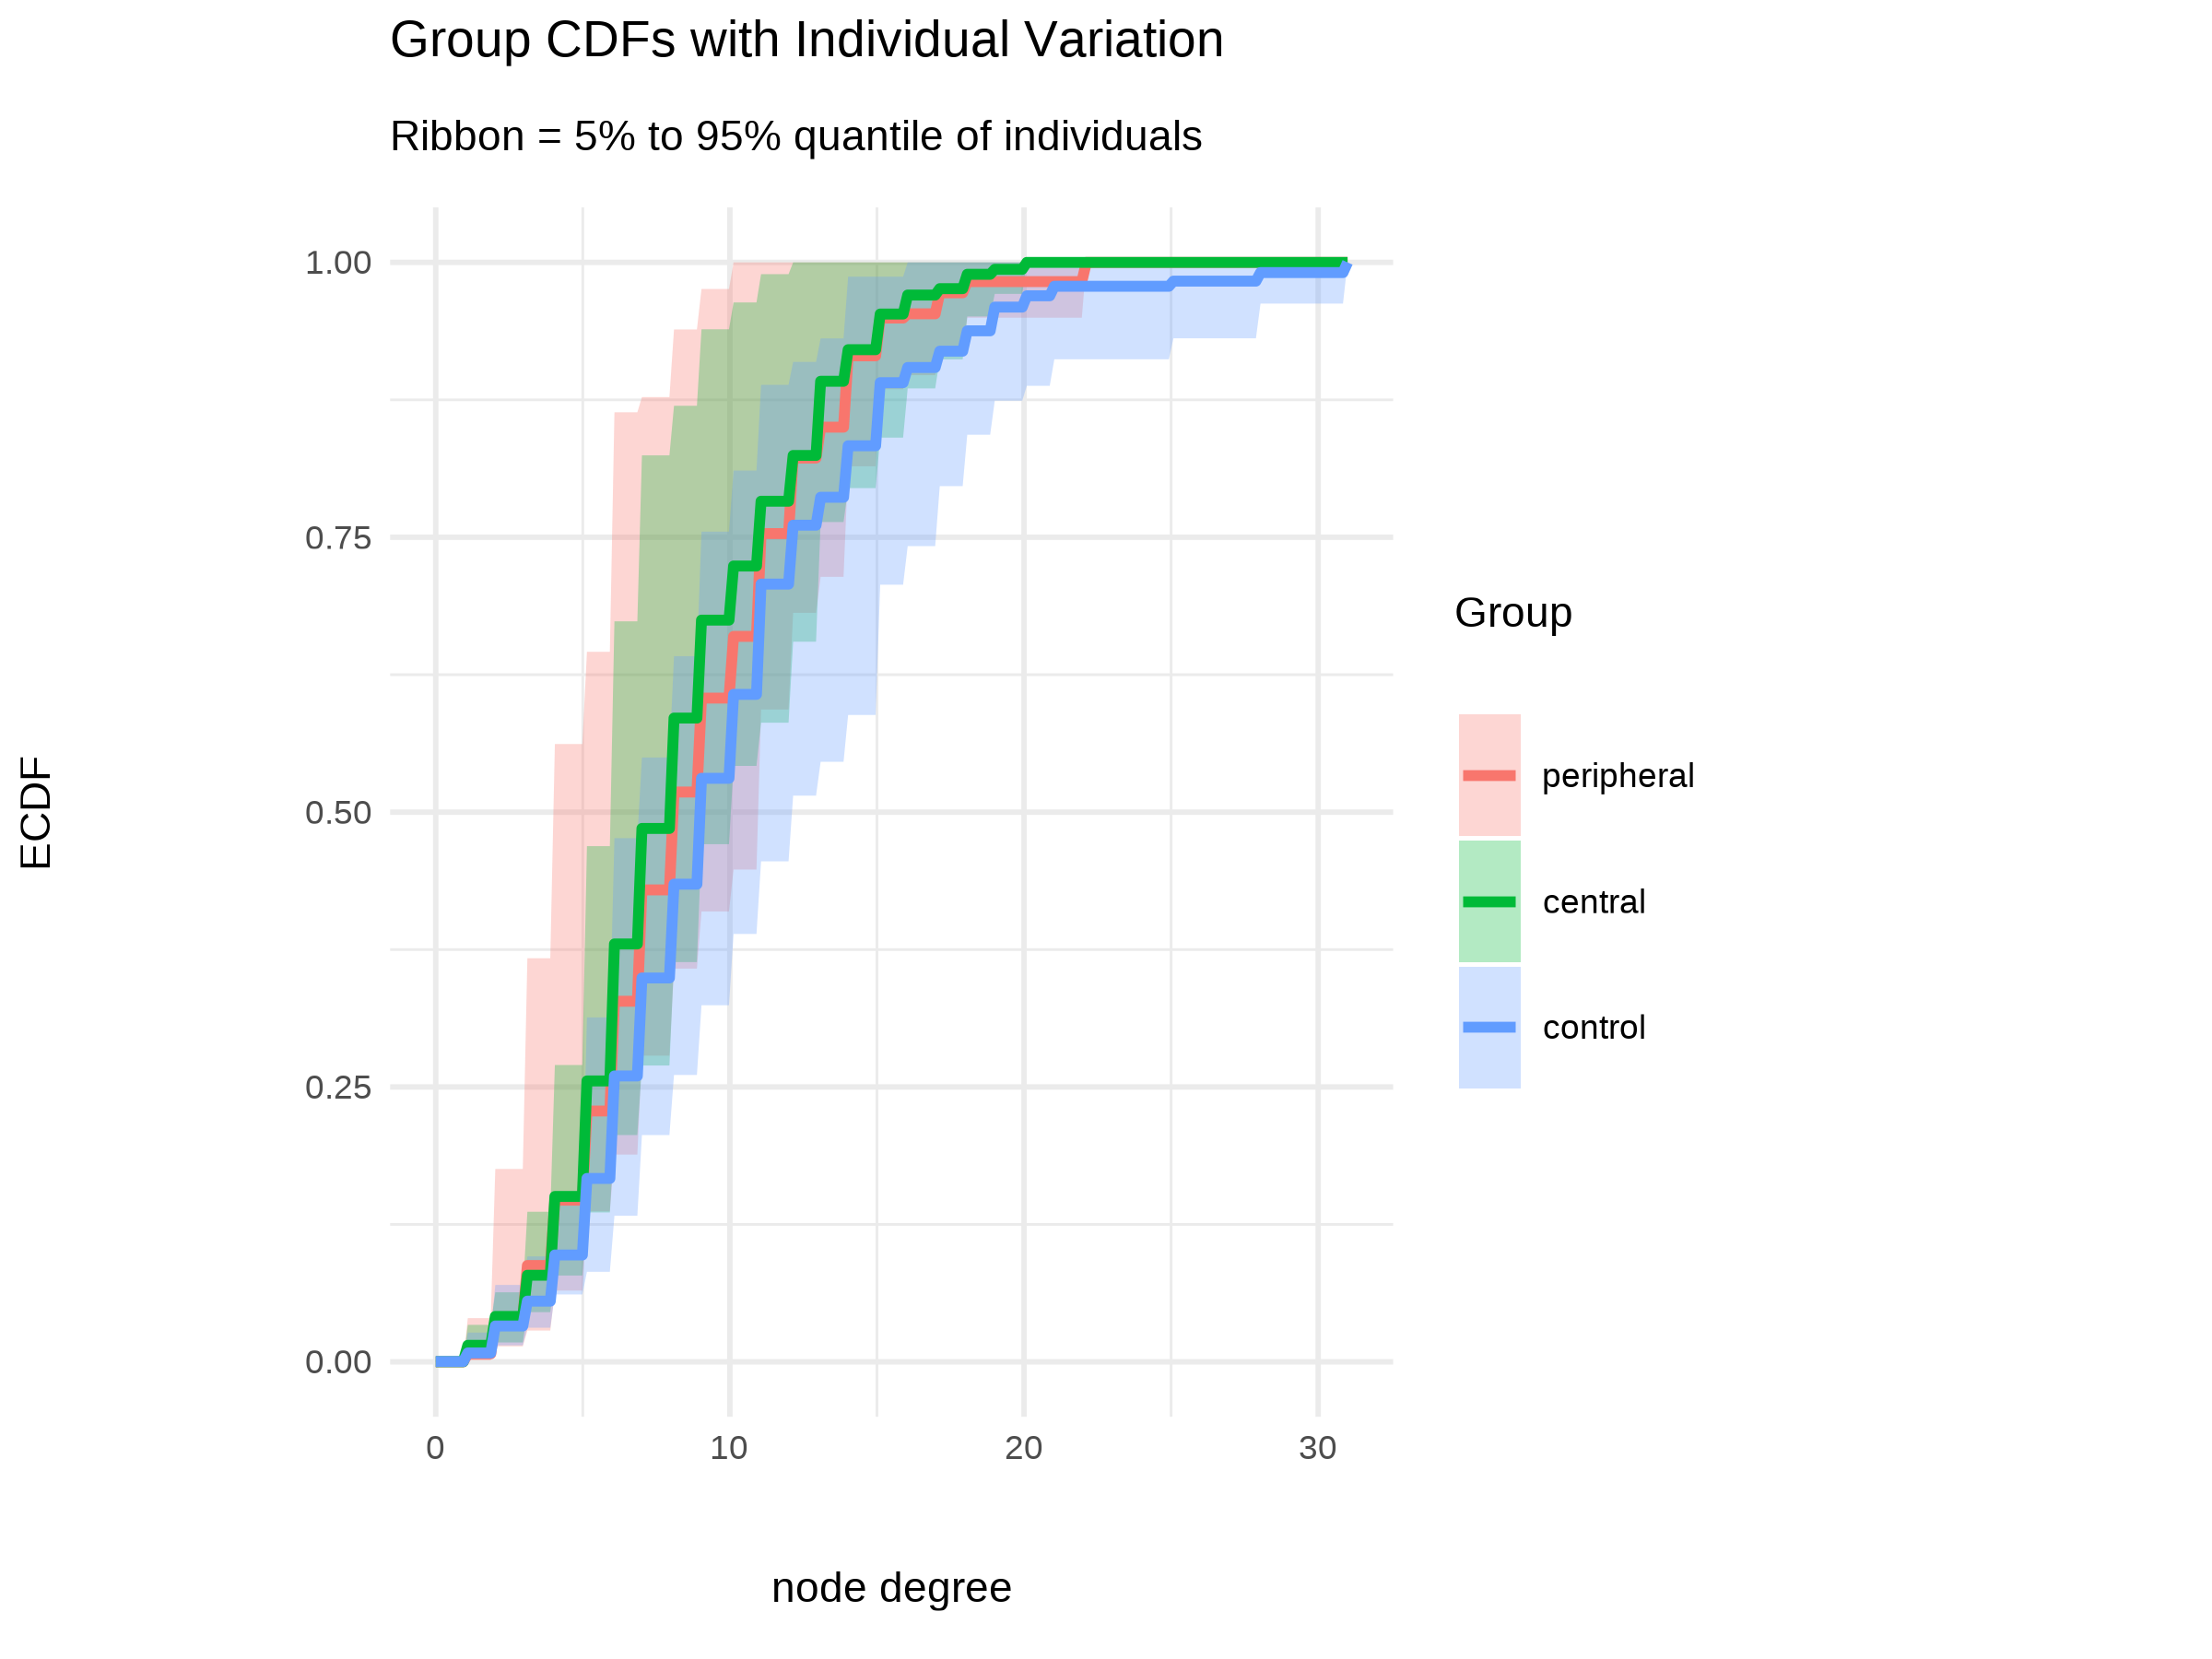

In [74]:
fig <- df_node |> plot_group_cdf_with_ribbon(connections, PID, group)
fig
# ggsave("group_node_degree_ecdf.svg", fig, width = 6, height = 6, units = "in", dpi = 300)

ERROR while rich displaying an object: Error in `geom_density()`:
! Problem while computing aesthetics.
ℹ Error occurred in the 1st layer.
Caused by error:
! object 'clusterDuration' not found

Traceback:
1. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
2. tryCatchList(expr, classes, parentenv, handlers)
3. tryCatchOne(expr, names, parentenv, handlers[[1L]])
4. doTryCatch(return(expr), name, parentenv, handler)
5. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = er

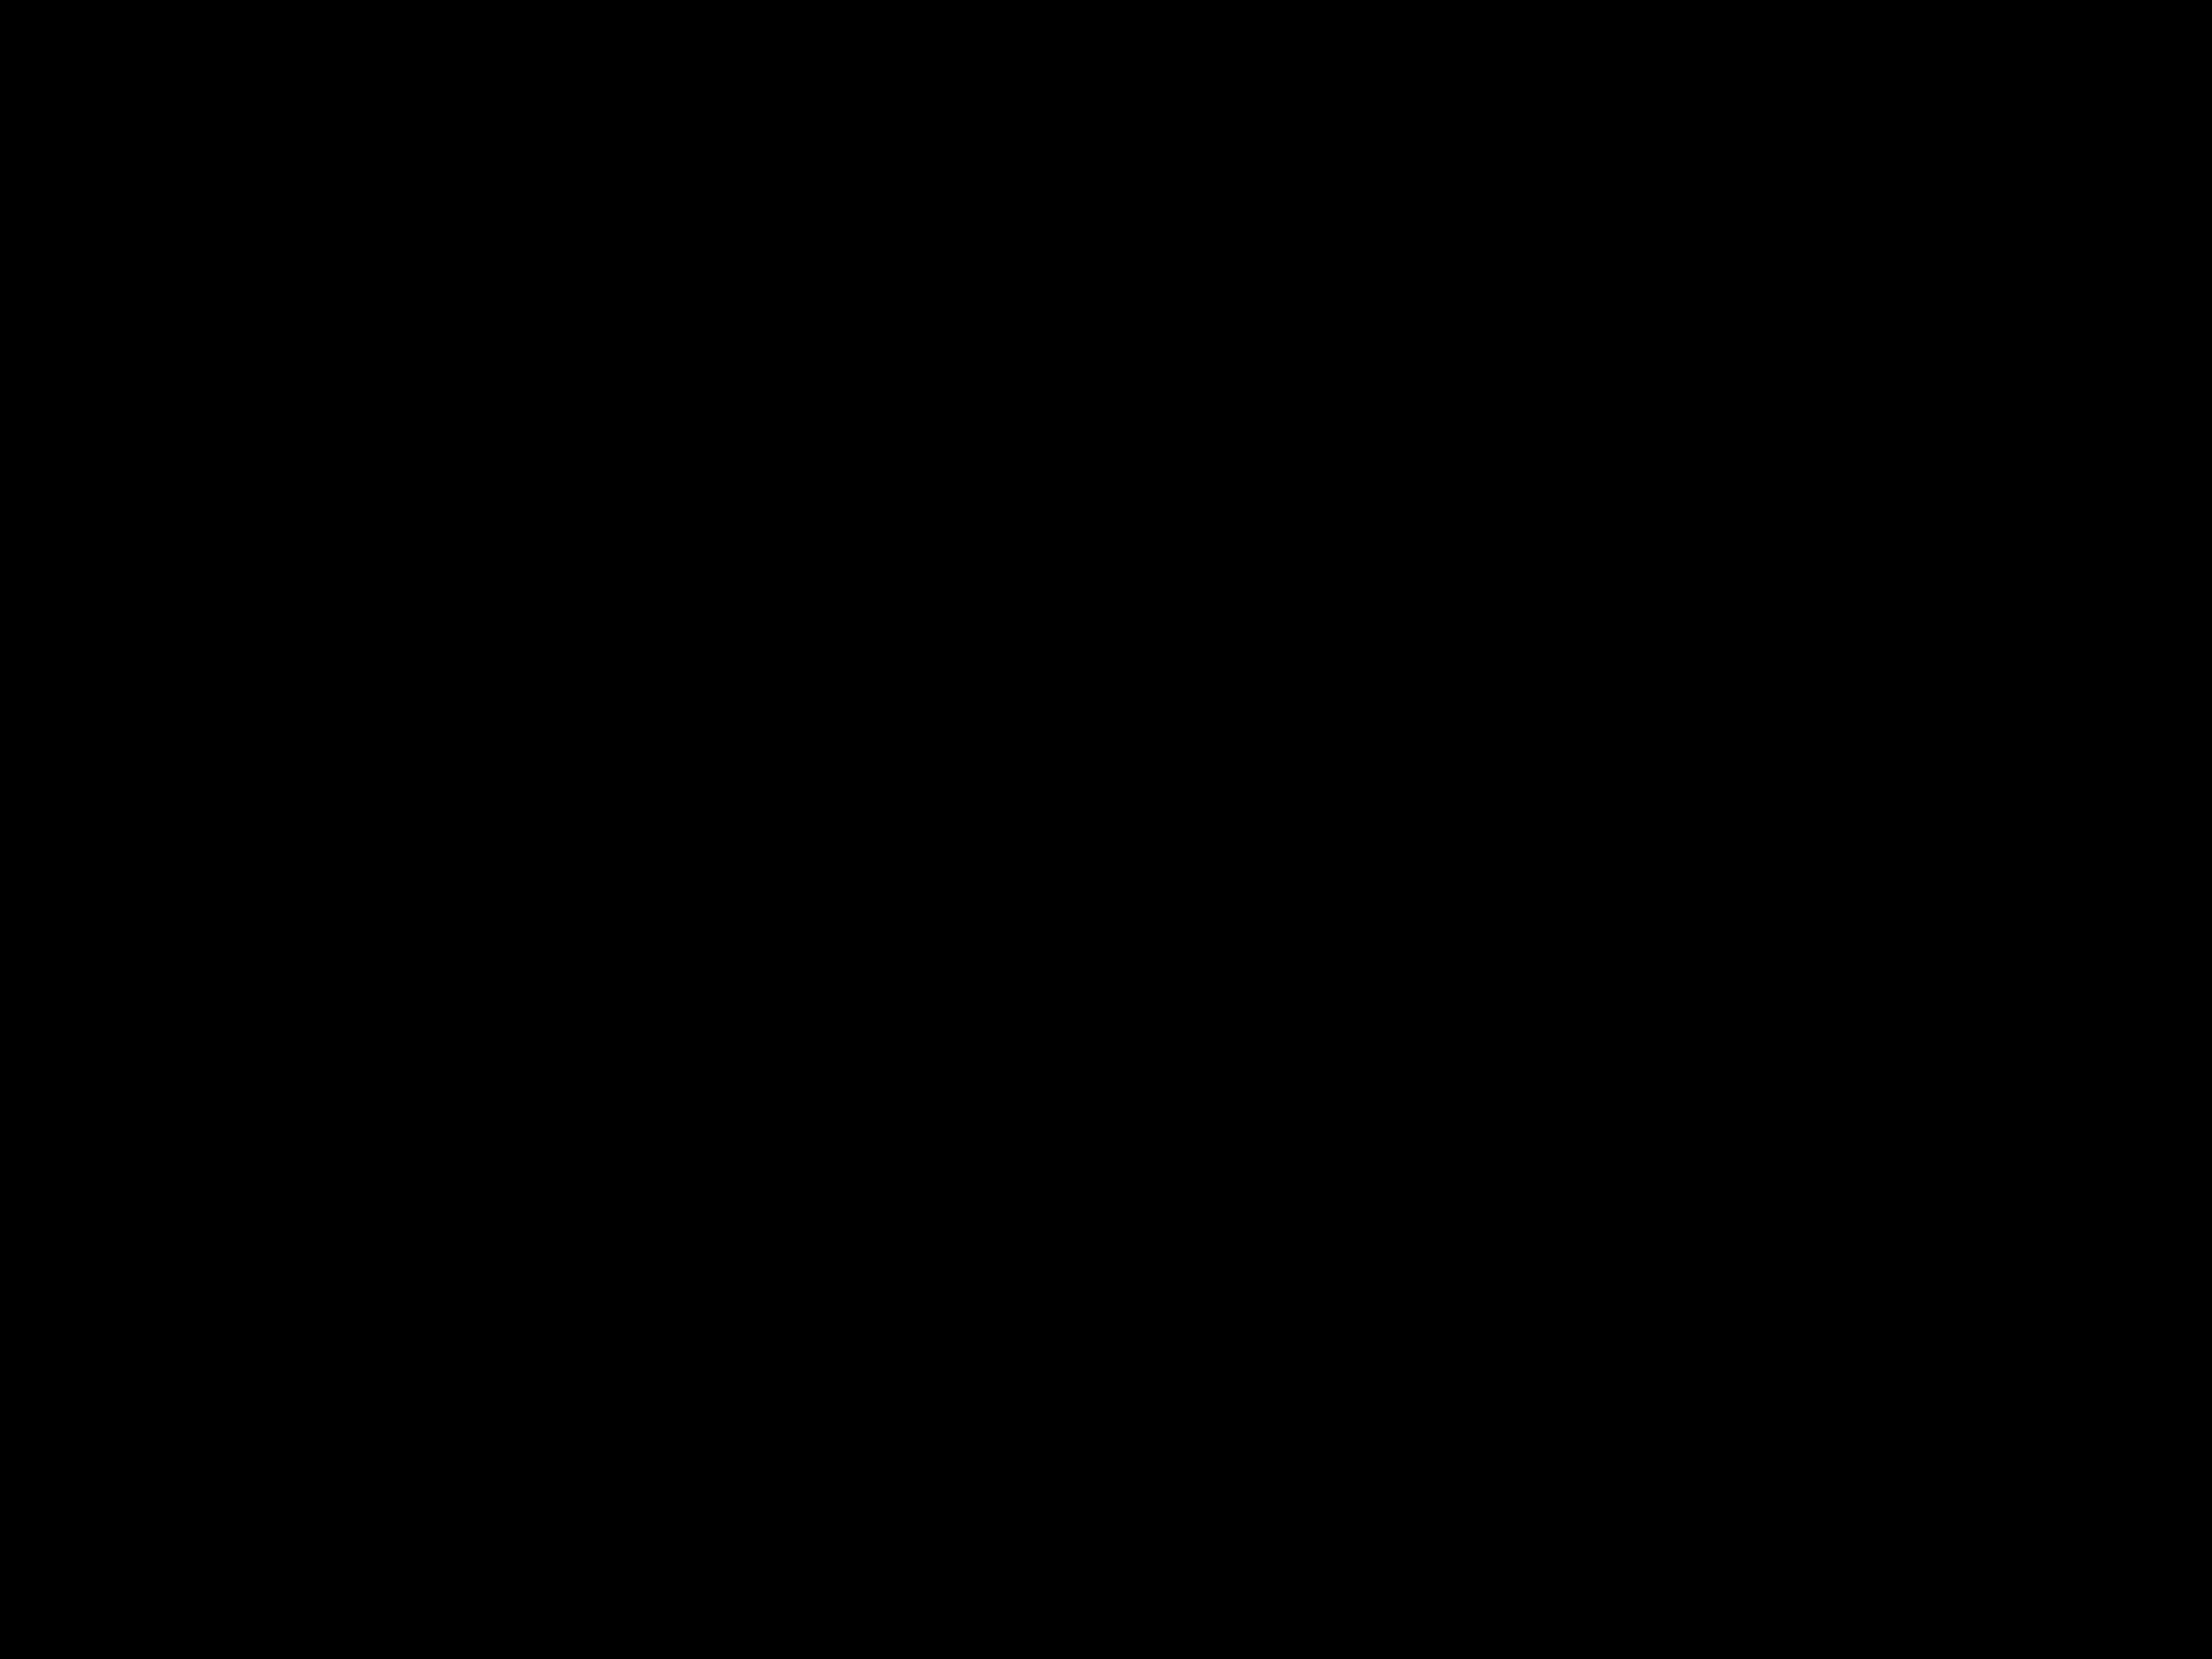

In [21]:
df_node |>
  ggplot(aes(x = clusterDuration)) +
  geom_density(alpha = 0.6) +  # Adjust alpha for transparency
  xlim(0,1)+
  facet_wrap(~ interaction(group, building_location)) +  # Facet by the interaction of the two factors
  theme_minimal() +
  labs(title = "Density Plot for Each Combination of Factors",
       x = "median cluster duration for each building (s)",
       y = "density")

In [22]:
df <- read_csv("graph_group_connections.csv")
df <- df |> 
    mutate(
        PID = factor(PID),
        category = factor(category, levels = c("peripheral", "central", "control")),
        hitObjectColliderName = factor(hitObjectColliderName)
    ) |>
    rename(
        group = category
    )

Rows: 1826 Columns: 4
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (2): hitObjectColliderName, category
dbl (2): PID, connections

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [39]:
fig <- df |>
  ggplot(aes(x = connections, group = group, color = group)) +
  geom_density(alpha = 0.6) +  # Adjust alpha for transparency
  theme_minimal() +
  labs(title = "Node degree centrality distribution",
       x = "node degree",
       y = "density")
#ggsave("sim_node_degree_dist.svg", fig)
fig

df_node |>
    group_by(PID, building, group, building_location, connections) |>
    ungroup() |>
    filter(connections > 10) |>
    ggplot(aes(x = duration)) +
      geom_density(alpha = 0.6) +  # Adjust alpha for transparency
      xlim(0,1)+
      facet_wrap(~ interaction(group, building_location)) +  # Facet by the interaction of the two factors
      theme_minimal() +
      labs(title = "Density Plot (node-degree > 10)",
           x = "median cluster duration for each building (s)",
           y = "density")
ggsave("naisu_only_location_node_filter.svg", fig)

Saving 6.67 x 6.67 in image


In [64]:
df_rm_null <- df_group_node |> filter(connections > 0)

model <- glmer(connections ~  group * building_location + (1 | PID), data = df_rm_null, Gamma(link = "inverse"))

In [63]:
# Create a reference grid
ref_grid <- ref_grid(model)
# Regrid to transform the reference grid
# This is particularly useful for gamma models with inverse link
new_grid <- regrid(ref_grid, transform = "response")

# Now use the transformed grid for emmeans
emm <- emmeans(new_grid, ~ building_location)

# View results
summary(emm)
pairs(emm, adjust = "bonferroni")
pairs(emm, adjust = "tukey")

,building_location,response,SE,df,asymp.LCL,asymp.UCL
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,outside,4.350301,0.1925744,Inf,3.972862,4.727740
2,inside,6.887977,0.4680248,Inf,5.970666,7.805289


 contrast         estimate    SE  df z.ratio p.value
 outside - inside    -2.54 0.311 Inf  -8.147  <.0001

Results are averaged over the levels of: group 

 contrast         estimate    SE  df z.ratio p.value
 outside - inside    -2.54 0.311 Inf  -8.147  <.0001

Results are averaged over the levels of: group 

In [65]:
model
library(car)
Anova(model)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( inverse )
Formula: connections ~ group * building_location + (1 | PID)
   Data: df_rm_null
      AIC       BIC    logLik  deviance  df.resid 
 9238.169  9282.248 -4611.084  9222.169      1818 
Random effects:
 Groups   Name        Std.Dev.
 PID      (Intercept) 0.02747 
 Residual             0.57017 
Number of obs: 1826, groups:  PID, 24
Fixed Effects:
                         (Intercept)                          groupcentral  
                            0.237722                              0.003478  
                        groupcontrol               building_locationinside  
                           -0.024330                             -0.072348  
groupcentral:building_locationinside  groupcontrol:building_locationinside  
                           -0.017550                             -0.016438  

,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
group,2.619834,2,2.698424e-01
building_location,310.818873,1,1.448236e-69
group:building_location,2.724093,2,2.561361e-01
